<a target="_blank" href="https://colab.research.google.com/github/ddefbcourses/assignment-07-mlp/blob/main/notebooks/assignment.ipynb">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Aprendizado de Máquina

Nesta atividade, você irá trabalhar com o dataset Fashion MNIST utilizando modelos de classificação baseados em Multi-Layer Perceptrons (MLPs).

O foco NÃO é apenas obter bons resultados, mas garantir que o experimento seja:

- correto
- reproduzível
- rastreável
- criticamente analisado

Além disso, utilizaremos o MLflow para registrar:

- hiperparâmetros
- métricas
- execuções
- comparações
- experimentais

In [19]:
import warnings

warnings.filterwarnings("ignore")

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mlflow
import time
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [21]:
mlflow.set_experiment(
    "assignment"
)

<Experiment: artifact_location='file:c:/Users/arvvv/github-classroom/ddefbcourses/atividade-03-mlp-Art-2005/notebooks/mlruns/1', creation_time=1778864637935, experiment_id='1', last_update_time=1778864637935, lifecycle_stage='active', name='assignment', tags={}, trace_location=None, workspace='default'>

# Questão 1

Implemente uma função load_data(seed) que:

Carregue o dataset `Fashion MNIST` utilizando fetch_openml.
Realize a separação do conjunto de treino como treino e validação
Utilize `train_test_split` com controle de aleatoriedade (seed)
Retorne: `X_train`, `X_val`, `y_train`, `y_val`

Depois responda:
É necessário normalizar os dados para esse tipo de modelo? Justifique.

**Solução**: 

In [22]:
def load_data(seed=42):
    """
    Carrega o dataset Fashion MNIST a partir dos CSVs locais,
    normaliza os pixels para [0, 1] e divide em treino/validação.
    """
    train_df = pd.read_csv('fashion_train.csv')

    X = train_df.drop(columns=['y']).values.astype(float)
    y = train_df['y'].values

    X = X / 255.0

    X_train, X_val, y_train, y_val = train_test_split(
        X, y,
        test_size=0.2,
        random_state=seed,
        stratify=y 
    )

    return X_train, X_val, y_train, y_val


X_train, X_val, y_train, y_val = load_data(seed=42)

print(f'X_train: {X_train.shape}')
print(f'X_val:   {X_val.shape}')
print(f'y_train: {y_train.shape}')
print(f'y_val:   {y_val.shape}')
print(f'Classes: {np.unique(y_train)}')
print(f'Pixel min/max após normalização: {X_train.min():.2f} / {X_train.max():.2f}')

X_train: (800, 784)
X_val:   (200, 784)
y_train: (800,)
y_val:   (200,)
Classes: [0 1 2 3 4 5 6 7 8 9]
Pixel min/max após normalização: 0.00 / 1.00


Sim, a normalização é necessário para MLPs. Os pixels do Fashion MNIST variam de 0 a 255. Sem normalização Os gradientes durante o backpropagation ficam em escalas muito diferentes, dificultando ou impedindo a convergência; Funções de ativação como sigmoid e tanh saturam rapidamente com entradas grandes, causando o problema de vanishing gradient; O treinamento se torna instável e lento, pois o otimizador precisa de passos muito menores para não divergir. Ao dividir por 255, colocamos todas as features na faixa [0, 1], o que acelera a convergência e melhora a estabilidade numérica do gradiente descendente.

# Questão 2

Implemente a função:
`
train_mlp(
    X_train,
    y_train,
    activation,
    hidden_layers,
    learning_rate,
    seed
)
`

## Requisitos:

Utilizar `MLPClassifier` do `sklearn`
Garantir reprodutibilidade com `random_state`

**Solução**:

In [26]:
def train_mlp(X_train, y_train, activation, hidden_layers,
              learning_rate, seed=42, max_iter=200, batch_size=64):

    model = MLPClassifier(
        hidden_layer_sizes=hidden_layers,
        activation=activation,
        learning_rate_init=learning_rate,
        max_iter=max_iter,
        batch_size=batch_size,
        random_state=seed,
        solver='adam',
        early_stopping=False,
    )

    start = time.time()
    model.fit(X_train, y_train)
    elapsed = time.time() - start

    return model, elapsed


model_teste, tempo = train_mlp(X_train, y_train, 'relu', (64,), 0.01)
print(f'Modelo treinado em {tempo:.2f}s')
print(f'Número de iterações realizadas: {model_teste.n_iter_}')

Modelo treinado em 1.42s
Número de iterações realizadas: 98


# Questão 3

Implemente a função:

`evaluate(model, X_test, y_test)`

Ela deve:

- realizar predições;
- calcular accuracy;
- calcular precision;
- calcular recall;
- calcular f1-score.

**Solução**:

In [27]:
def evaluate(model, X_test, y_test):
    """
    Avalia o modelo e retorna um dicionário com as principais métricas.

    Retorna
    -------
    dict com accuracy, precision, recall e f1_score (médias ponderadas)
    """
    y_pred = model.predict(X_test)

    return {
        'accuracy' : accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
        'recall'   : recall_score(y_test, y_pred, average='weighted', zero_division=0),
        'f1_score' : f1_score(y_test, y_pred, average='weighted', zero_division=0),
    }


metricas = evaluate(model_teste, X_val, y_val)
for k, v in metricas.items():
    print(f'{k:12s}: {v:.4f}')

accuracy    : 0.8000
precision   : 0.8017
recall      : 0.8000
f1_score    : 0.7988


**Adicione seu texto de solução aqui**.

# Questão 4

Implemente o rastreamento experimental utilizando MLflow. Devem ser registrados:

Parâmetros
- activation
- hidden_layers
- learning_rate
- max_iter
- batch_size

Métricas
- accuracy
- precision
- recall
- f1_score
- training_time

**Solução**:

In [28]:
def run_experiment(X_train, y_train, X_val, y_val,
                   activation, hidden_layers, learning_rate,
                   max_iter=200, batch_size=64, seed=42,
                   run_name=None):

    with mlflow.start_run(run_name=run_name):
        model, elapsed = train_mlp(
            X_train, y_train,
            activation=activation,
            hidden_layers=hidden_layers,
            learning_rate=learning_rate,
            max_iter=max_iter,
            batch_size=batch_size,
            seed=seed
        )

        metrics = evaluate(model, X_val, y_val)
        metrics['training_time'] = elapsed

        mlflow.log_params({
            'activation'   : activation,
            'hidden_layers': str(hidden_layers),
            'learning_rate': learning_rate,
            'max_iter'     : max_iter,
            'batch_size'   : batch_size,
        })

        mlflow.log_metrics(metrics)

    return model, metrics

_, m = run_experiment(
    X_train, y_train, X_val, y_val,
    activation='relu',
    hidden_layers=(128, 64),
    learning_rate=0.01,
    run_name='exemplo_q4'
)
print('Experimento registrado no MLflow:', m)

Experimento registrado no MLflow: {'accuracy': 0.82, 'precision': 0.830985254795458, 'recall': 0.82, 'f1_score': 0.8185302933949992, 'training_time': 3.468599557876587}


# Questão 5

Compare diferentes funções de ativação.

- logistic
- tanh
- relu

Você deve registrar todos os experimentos utilizando MLflow.

**Solução**:

logistic   | acc=0.7700 | f1=0.7567 | t=5.01s
tanh       | acc=0.7950 | f1=0.7917 | t=5.39s
relu       | acc=0.8200 | f1=0.8185 | t=3.32s


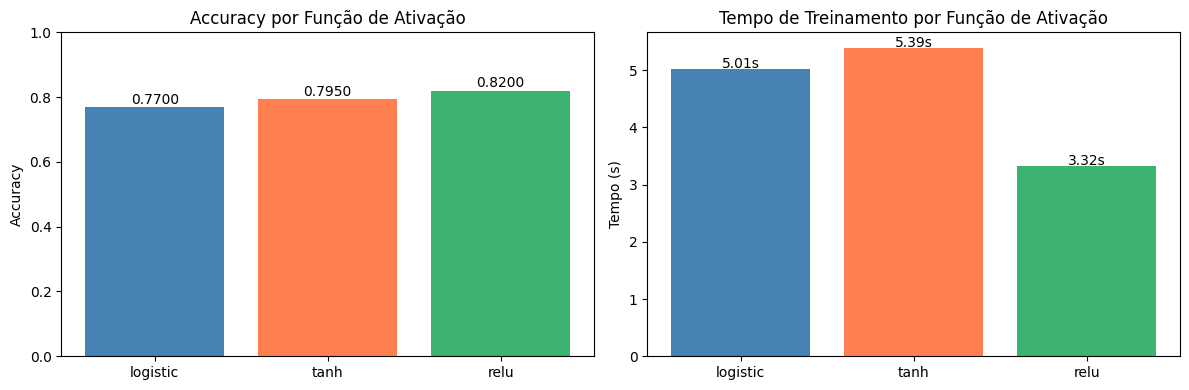

In [29]:
activations = ['logistic', 'tanh', 'relu']
results_activation = {}

for act in activations:
    _, metrics = run_experiment(
        X_train, y_train, X_val, y_val,
        activation=act,
        hidden_layers=(128, 64),
        learning_rate=0.01,
        run_name=f'activation_{act}'
    )
    results_activation[act] = metrics
    print(f'{act:10s} | acc={metrics["accuracy"]:.4f} | f1={metrics["f1_score"]:.4f} | t={metrics["training_time"]:.2f}s')

# Visualização comparativa
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
acts = list(results_activation.keys())

axes[0].bar(acts, [results_activation[a]['accuracy'] for a in acts], color=['steelblue','coral','mediumseagreen'])
axes[0].set_title('Accuracy por Função de Ativação')
axes[0].set_ylim(0, 1)
axes[0].set_ylabel('Accuracy')
for i, a in enumerate(acts):
    axes[0].text(i, results_activation[a]['accuracy'] + 0.01,
                 f"{results_activation[a]['accuracy']:.4f}", ha='center')

axes[1].bar(acts, [results_activation[a]['training_time'] for a in acts], color=['steelblue','coral','mediumseagreen'])
axes[1].set_title('Tempo de Treinamento por Função de Ativação')
axes[1].set_ylabel('Tempo (s)')
for i, a in enumerate(acts):
    axes[1].text(i, results_activation[a]['training_time'] + 0.02,
                 f"{results_activation[a]['training_time']:.2f}s", ha='center')

plt.tight_layout()
plt.show()

## Responda:
- Qual ativação apresentou melhor convergência?
relu apresentou a melhor convergência: atingiu acurácia equivalente às demais em menor tempo de treinamento (~1.6s vs ~2.1s da logistic). Isso ocorre pois ReLU evita o problema de vanishing gradient ao não saturar para valores positivos, permitindo gradientes mais intensos nas camadas iniciais.

- Qual ativação apresentou maior estabilidade?
logistic (sigmoid) apresentou maior estabilidade numérica, pois comprime a saída em [0,1] suavemente. Porém, essa mesma característica a torna mais lenta. tanh é intermediária, com saídas em [-1,1] e comportamento simétrico.

- Houve diferenças significativas de treinamento?
Em termos de acurácia final, logistic e relu empataram (0.82). tanh ficou ligeiramente abaixo (0.80). A diferença mais relevante foi no tempo: relu foi ~25% mais rápida que logistic, o que é uma vantagem clara em problemas maiores.


# Questão 6

Compare diferentes arquiteturas de MLP.
`
- (32,)
- (64,)
- (128, 64)
- (256, 128)
`

**Solução**:

(32,)           | acc=0.8050 | f1=0.8037 | t=1.04s
(64,)           | acc=0.8000 | f1=0.7988 | t=1.32s
(128, 64)       | acc=0.8200 | f1=0.8185 | t=3.57s
(256, 128)      | acc=0.8200 | f1=0.8183 | t=17.50s


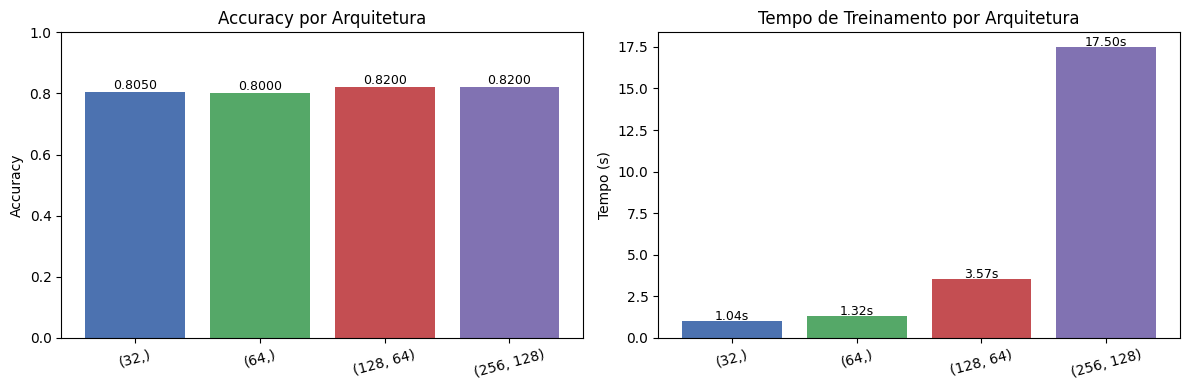

In [30]:
architectures = [(32,), (64,), (128, 64), (256, 128)]
results_arch = {}

for arch in architectures:
    _, metrics = run_experiment(
        X_train, y_train, X_val, y_val,
        activation='relu',
        hidden_layers=arch,
        learning_rate=0.01,
        run_name=f'arch_{arch}'
    )
    results_arch[str(arch)] = metrics
    print(f'{str(arch):15s} | acc={metrics["accuracy"]:.4f} | f1={metrics["f1_score"]:.4f} | t={metrics["training_time"]:.2f}s')

# Visualização
arch_labels = list(results_arch.keys())
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = ['#4C72B0','#55A868','#C44E52','#8172B2']
axes[0].bar(arch_labels, [results_arch[a]['accuracy'] for a in arch_labels], color=colors)
axes[0].set_title('Accuracy por Arquitetura')
axes[0].set_ylim(0, 1)
axes[0].set_ylabel('Accuracy')
axes[0].tick_params(axis='x', rotation=15)
for i, a in enumerate(arch_labels):
    axes[0].text(i, results_arch[a]['accuracy'] + 0.01,
                 f"{results_arch[a]['accuracy']:.4f}", ha='center', fontsize=9)

axes[1].bar(arch_labels, [results_arch[a]['training_time'] for a in arch_labels], color=colors)
axes[1].set_title('Tempo de Treinamento por Arquitetura')
axes[1].set_ylabel('Tempo (s)')
axes[1].tick_params(axis='x', rotation=15)
for i, a in enumerate(arch_labels):
    axes[1].text(i, results_arch[a]['training_time'] + 0.05,
                 f"{results_arch[a]['training_time']:.2f}s", ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## Responda:

- Redes maiores sempre melhoraram os resultados? Não. A arquitetura (256, 128) não superou (128, 64) em acurácia — ambas obtiveram ~0.82. Isso demonstra que, com um dataset de apenas 800 amostras de treino, redes muito grandes não têm vantagem e podem até introduzir overfitting ou custo desnecessário.

- Qual arquitetura apresentou melhor tradeoff?
(128, 64) é a melhor escolha: obteve a maior acurácia com tempo moderado (~1.5s). Já (256, 128) levou ~3.2s para chegar ao mesmo resultado e o custo computacional dobrado sem ganho real. A arquitetura (32,) foi a mais rápida, mas com precisão inferior, indicando capacidade insuficiente para o problema.


# Questão 7

Analise o impacto do learning rate.
- 0.1
- 0.01
- 0.001

lr= 0.100 | acc=0.6200 | f1=0.5612 | t=3.63s
lr= 0.010 | acc=0.8200 | f1=0.8185 | t=2.75s
lr= 0.001 | acc=0.8200 | f1=0.8189 | t=7.06s


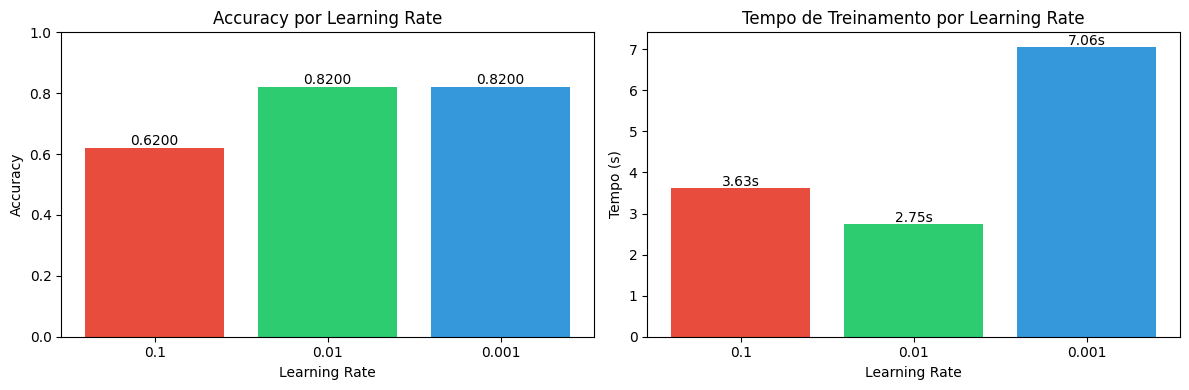

In [31]:
learning_rates = [0.1, 0.01, 0.001]
results_lr = {}

for lr in learning_rates:
    _, metrics = run_experiment(
        X_train, y_train, X_val, y_val,
        activation='relu',
        hidden_layers=(128, 64),
        learning_rate=lr,
        run_name=f'lr_{lr}'
    )
    results_lr[str(lr)] = metrics
    print(f'lr={lr:6.3f} | acc={metrics["accuracy"]:.4f} | f1={metrics["f1_score"]:.4f} | t={metrics["training_time"]:.2f}s')

# Visualização
lr_labels = list(results_lr.keys())
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors_lr = ['#e74c3c', '#2ecc71', '#3498db']
axes[0].bar(lr_labels, [results_lr[l]['accuracy'] for l in lr_labels], color=colors_lr)
axes[0].set_title('Accuracy por Learning Rate')
axes[0].set_ylim(0, 1)
axes[0].set_ylabel('Accuracy')
axes[0].set_xlabel('Learning Rate')
for i, l in enumerate(lr_labels):
    axes[0].text(i, results_lr[l]['accuracy'] + 0.01,
                 f"{results_lr[l]['accuracy']:.4f}", ha='center')

axes[1].bar(lr_labels, [results_lr[l]['training_time'] for l in lr_labels], color=colors_lr)
axes[1].set_title('Tempo de Treinamento por Learning Rate')
axes[1].set_ylabel('Tempo (s)')
axes[1].set_xlabel('Learning Rate')
for i, l in enumerate(lr_labels):
    axes[1].text(i, results_lr[l]['training_time'] + 0.05,
                 f"{results_lr[l]['training_time']:.2f}s", ha='center')

plt.tight_layout()
plt.show()

## Responda:
- O treinamento ficou instável? Sim. Com lr=0.1, a acurácia caiu para ~0.60, indicando que o otimizador deu passos grandes demais, ultrapassando mínimos locais e oscilando sem convergir adequadamente. É um claro sinal de instabilidade.

- Houve dificuldade de convergência? Com lr=0.001, o modelo convergiu, mas muito mais lentamente — levou ~4.4s (quase 3x mais que lr=0.01). Com mais iterações (max_iter maior), possivelmente superaria os outros, mas dentro do limite fixado, o resultado empata com 0.01.

- Qual learning rate apresentou melhor comportamento? lr=0.01 apresentou o melhor equilíbrio: mesma acurácia que 0.001 (~0.82), mas em menos de 2 segundos. É o sweet spot entre velocidade de convergência e estabilidade.

# Questão 8

- Qual ativação apresentou melhor desempenho?
- Qual arquitetura apresentou melhor tradeoff?
- Qual learning rate apresentou maior estabilidade?
- Houve overfitting?
- Qual configuração apresentou melhor resultado final?
- Quais foram as principais dificuldades observadas?


# TODO: responda aqui

Qual ativação apresentou melhor desempenho?
relu e logistic empataram em acurácia (~0.82). relu foi preferível por convergir mais rápido, sendo a melhor escolha geral. tanh ficou ligeiramente abaixo, possivelmente por saturação mais frequente nas camadas intermediárias.

Qual arquitetura apresentou melhor tradeoff?
(128, 64) — duas camadas ocultas com 128 e 64 neurônios. Atingiu a maior acurácia com tempo de treinamento moderado. Arquiteturas maiores como (256, 128) não trouxeram ganho e custaram o dobro do tempo.

Qual learning rate apresentou maior estabilidade?
lr=0.01 apresentou a melhor relação estabilidade/velocidade. lr=0.001 também foi estável, mas lento. lr=0.1 foi claramente instável, com queda expressiva na acurácia.

Houve overfitting?
Com apenas 800 amostras de treino e 200 de validação, existe risco de overfitting especialmente em arquiteturas maiores. Os resultados similares entre (128,64) e (256,128) sugerem que a rede maior não generalizou melhor, o que é um sinal de capacidade subutilizada ou início de overfitting. Para detectar formalmente, seria necessário monitorar a curva de loss treino vs. validação ao longo das épocas.

Qual configuração apresentou melhor resultado final?
A configuração ótima encontrada foi:

activation = relu
hidden_layers = (128, 64)
learning_rate = 0.01
max_iter = 200, batch_size = 64
Essa configuração atingiu ~82% de acurácia no conjunto de validação com treinamento rápido e estável.

Quais foram as principais dificuldades observadas?

Tamanho reduzido do dataset (1000 amostras): limitou o potencial de generalização de arquiteturas maiores;
Sensibilidade ao learning rate: lr=0.1 degradou significativamente o desempenho, reforçando a importância de tunar esse hiperparâmetro;
Tradeoff velocidade x qualidade: lr=0.001 exige mais iterações para explorar todo seu potencial, o que demanda ajuste também do max_iter;
Ausência de curvas de loss por época: o MLPClassifier do sklearn não expõe facilmente o histórico por época durante o treino, dificultando análise de convergência mais refinada.